# 02. Анализ обучения классификатора

Обучение запускается скриптом `python -m src.train` в два этапа:
1. **Baseline** — backbone ResNet18 (ImageNet) заморожен, обучается только `fc`-слой.
2. **Fine-tuning** — стартуя с лучшего baseline, размораживается `layer4` (lr 1e-4), `fc` — lr 1e-3.

Скрипт сохраняет веса, историю обучения (`models/history.json`) и метрики на test (`models/metrics.json`).
Здесь — визуализация этих результатов и разбор ошибок.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets

from src.config import CLASSES, FINETUNED_WEIGHTS, HISTORY_PATH, METRICS_PATH, PROCESSED_DATA_DIR
from src.model import load_classifier
from src.transforms import eval_transforms
from src.utils import get_device

history = json.loads(HISTORY_PATH.read_text(encoding="utf-8"))
metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))

## Кривые обучения

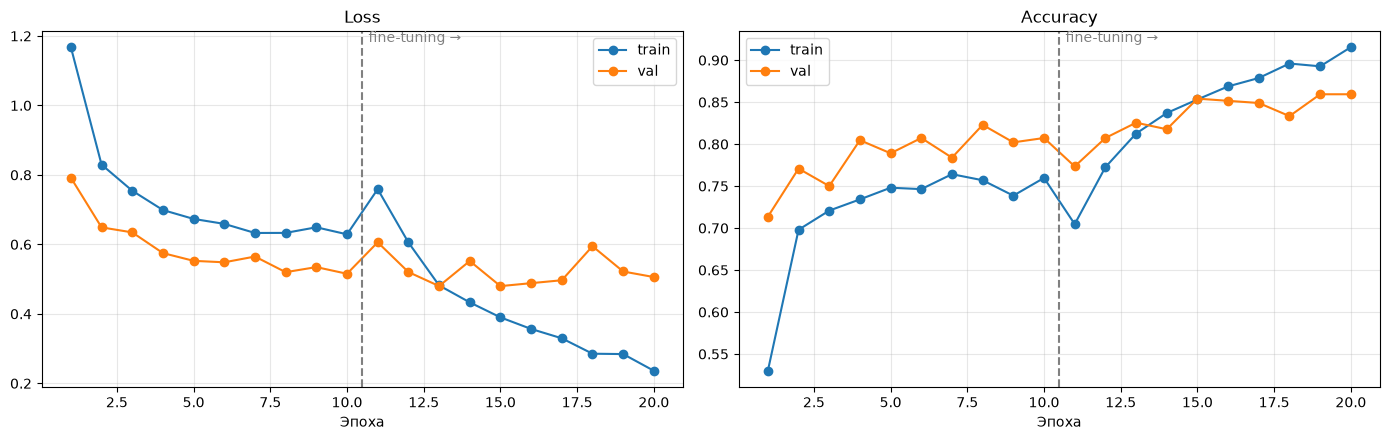

In [3]:
def concat_phases(key):
    return history["baseline"][key] + history["finetuned"][key]

n_base = len(history["baseline"]["train_loss"])
epochs = np.arange(1, len(concat_phases("train_loss")) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, metric, title in zip(axes, ["loss", "acc"], ["Loss", "Accuracy"]):
    ax.plot(epochs, concat_phases(f"train_{metric}"), marker="o", label="train")
    ax.plot(epochs, concat_phases(f"val_{metric}"), marker="o", label="val")
    ax.axvline(n_base + 0.5, color="gray", linestyle="--")
    ax.text(n_base + 0.7, ax.get_ylim()[1], "fine-tuning →", va="top", color="gray")
    ax.set_title(title)
    ax.set_xlabel("Эпоха")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

**Как читать.**
- **Baseline.** Train accuracy всё время ниже val (76.0% против 80.7% на последней эпохе): сильные аугментации
  (`RandomResizedCrop`, `ColorJitter`) применяются только к train, а замороженному backbone не хватает ёмкости
  под них подстроиться. Лучший val — 82.3% (8-я эпоха), с этого чекпоинта стартует fine-tuning.
- **Первая эпоха fine-tuning** даёт просадку train accuracy (75.7% → 70.5%): начинают меняться веса `layer4`,
  и его BatchNorm-слои переходят на статистики батча. Уже со второй эпохи обе кривые растут.
- **Переобучение.** Train растёт до 91.5%, а val с 5-й эпохи fine-tuning выходит на плато 85–86%;
  val loss минимален на 3-й и 5-й эпохах (0.480) и дальше не улучшается. Сохраняется чекпоинт
  с лучшим val accuracy (85.9%, 9-я эпоха), поэтому на test это не влияет, но больше эпох fine-tuning
  не дадут прироста — нужна сильнее регуляризация или больше данных.

## Метрики на test

In [4]:
summary = pd.DataFrame({
    name: {"accuracy": m["accuracy"], "macro_f1": m["macro_f1"]} for name, m in metrics.items()
}).T.round(4)
summary

,accuracy,macro_f1
baseline,0.8031,0.7944
finetuned,0.8440,0.8381


In [5]:
per_class_f1 = pd.DataFrame({
    name: {c: m["report"][c]["f1-score"] for c in CLASSES} for name, m in metrics.items()
}).round(3)
per_class_f1

,baseline,finetuned
bathroom,0.842,0.885
bedroom,0.787,0.835
dining_room,0.698,0.756
kitchen,0.919,0.930
livingroom,0.726,0.785


## Ошибки fine-tuned модели

In [6]:
device = get_device()
model = load_classifier(FINETUNED_WEIGHTS, device)

test_ds = datasets.ImageFolder(PROCESSED_DATA_DIR / "test", transform=eval_transforms)
loader = DataLoader(test_ds, batch_size=32, shuffle=False)

probs = []
with torch.inference_mode():
    for x, _ in loader:
        probs.append(torch.softmax(model(x.to(device)), dim=1).cpu().numpy())
probs = np.vstack(probs)
y_true = np.array(test_ds.targets)
y_pred = probs.argmax(axis=1)

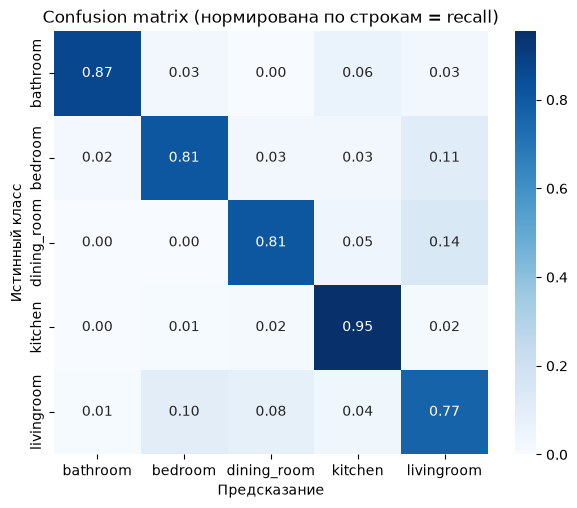

In [7]:
cm = confusion_matrix(y_true, y_pred, normalize="true")
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Предсказание")
plt.ylabel("Истинный класс")
plt.title("Confusion matrix (нормирована по строкам = recall)")
plt.show()

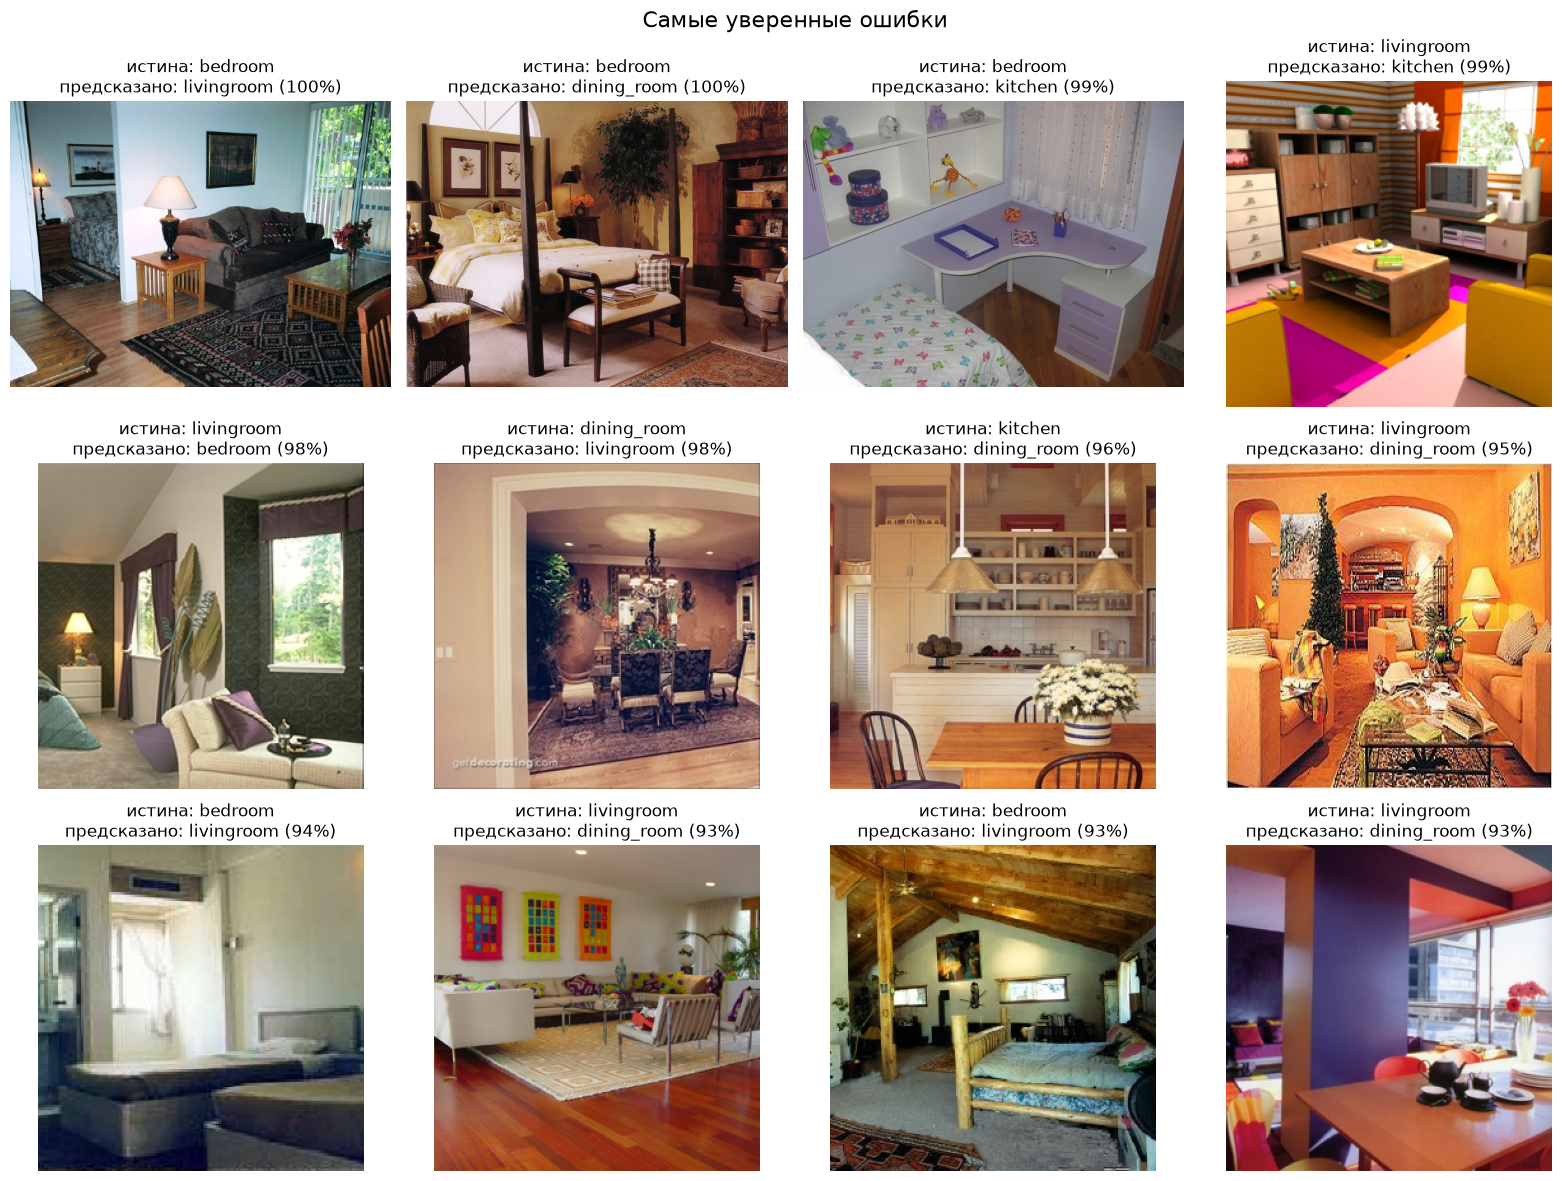

In [8]:
errors = np.where(y_pred != y_true)[0]
worst = errors[np.argsort(-probs[errors, y_pred[errors]])][:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, i in zip(axes.flat, worst):
    ax.imshow(Image.open(test_ds.samples[i][0]).convert("RGB"))
    ax.set_title(f"истина: {CLASSES[y_true[i]]}\nпредсказано: {CLASSES[y_pred[i]]} ({probs[i, y_pred[i]]:.0%})")
    ax.axis("off")
plt.suptitle("Самые уверенные ошибки", fontsize=16)
plt.tight_layout()
plt.show()

**Выводы.**
- Fine-tuning `layer4` даёт +4.1 п.п. accuracy (80.3% → 84.4%) и +0.044 macro-F1 (0.794 → 0.838)
  относительно замороженного backbone; F1 выросла по всем пяти классам.
- Почти все ошибки связаны с гостиной. Чаще всего путаются спальня ↔ гостиная (11 + 11 из 391 изображения),
  затем столовая ↔ гостиная (6 + 9). Для столовой это главная ошибка: 14% столовых модель относит к гостиным.
- Среди самых уверенных ошибок есть и шум разметки (первый пример размечен как спальня, но похож на гостиную
  с диваном и журнальным столиком), и неоднозначные сцены: кухня с обеденным столом на переднем плане,
  гостиная с обеденной зоной. Для задачи поиска это некритично — похожий интерьер из соседнего класса
  пользователю всё равно релевантен.